In [3]:
import GPy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pb
import pylab as pb
import pandas as pd
import helpers.processing as processing
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [4]:
training_data = pd.read_csv("sand_data_alumina.csv")
training_data.columns

Index(['Minutes', 'total_flowrate', 'fl_L1', 'fl_L2', 'total_bed_height', 'p1',
       'flowrate_combi', 'bed_exp', 'initial_bed_height', 'step_size',
       'normalized_p'],
      dtype='object')

In [5]:
targets = ["p1"]  # ["p1"]
independent_variables = ["fl_L1", "fl_L2", "initial_bed_height"]
num_inputs = len(independent_variables)

In [6]:
# scaling
scalerx = StandardScaler()
scalery = StandardScaler()

train_indvar = scalerx.fit_transform(training_data[independent_variables])
# train_target = scalery.fit_transform(training_data[targets])

In [7]:
# defining kernel
# kernel = GPy.kern.RBF(input_dim=num_inputs, ARD=False)
kernel = GPy.kern.Exponential(input_dim=num_inputs, ARD=False)
# kernel = GPy.kern.RBF(
#     input_dim=num_inputs,
#     ARD=True,
#     # lengthscale=np.array([0.312067795, 7.91086464e4, 1.62688649]),
#     variance=0.9001744123027393,
# )
# kernel = GPy.kern.Matern52(input_dim=num_inputs, ARD=False)

# kernel.lengthscale.constrain_bounded(1e-5, 1e5)
# kernel.variance.constrain_bounded(1e-5, 1e5)
# kernel.parts[1].variance.constrain_bounded(1e-5, 1e5)

# Set bounds for variance and lengthscales to match scikit-learn
# kernel.variance.constrain_bounded(1e-5, 1e5)
# kernel.lengthscale.constrain_bounded(1e-5, 1e5)
model = GPy.models.GPRegression(
    train_indvar, training_data[targets], kernel, normalizer=True
)
model.optimize(messages=True)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s01  0006  -2.034451e+00   5.974316e+00 
    00s02  0011  -3.060500e+00   3.409077e-02 
    00s06  0029  -3.210823e+00   1.400864e-02 
    00s06  0031  -3.221452e+00   4.191321e-03 
    00s07  0036  -3.223149e+00   6.442714e-12 
    00s07  0037  -3.223149e+00   6.442714e-12 
Runtime:     00s07
Optimization status: Converged



In [8]:
model.optimize_restarts(num_restarts=40)

Optimization restart 1/40, f = -3.223149307964931
Optimization restart 2/40, f = -3.174980195759378
Optimization restart 3/40, f = -3.174980163799944
Optimization restart 4/40, f = -3.174995387719953
Optimization restart 5/40, f = -3.1749943792079733
Optimization restart 6/40, f = -3.2231493079614637
Optimization restart 7/40, f = -3.1749867078450933
Optimization restart 8/40, f = -3.2231493078474607
Optimization restart 9/40, f = -3.223149307941057
Optimization restart 10/40, f = -3.2231493080212346
Optimization restart 11/40, f = -3.174980176641192
Optimization restart 12/40, f = -3.1749876123717584
Optimization restart 13/40, f = -3.174980165356917
Optimization restart 14/40, f = -3.174980164038889
Optimization restart 15/40, f = -3.1749879798578355
Optimization restart 16/40, f = -3.2231493079602664
Optimization restart 17/40, f = -3.2231493072745856
Optimization restart 18/40, f = -3.2231493079505604
Optimization restart 19/40, f = -3.2231493078301767
Optimization restart 20/40, f

In [9]:
model.parameters

In [10]:
from IPython.display import display

display(model)

GP_regression.,value,constraints,priors
Exponential.variance,3.8347469486011025,+ve,
Exponential.lengthscale,18.50637017593352,+ve,
Gaussian_noise.variance,2.73702564745228e-06,+ve,


In [11]:
num_pred = 1000

# corresponding to 0.872m
l2 = np.ones(num_pred).ravel() * 15
# l2[:100] = 0
flowrate_range = np.vstack(
    [
        np.linspace(0, 250, num_pred).ravel(),
        l2,
    ]
).T

totalflowrate = flowrate_range.sum(axis=1)
prediction_inputs = np.hstack(
    [
        flowrate_range,
        # np.ones(flowrate_range.shape[0]).reshape(-1, 1) * 50,
        np.ones(flowrate_range.shape[0]).reshape(flowrate_range.shape[0], 1) * 0.872,
    ]
)
print(prediction_inputs.shape)

(1000, 3)


In [12]:
prediction_inputs.shape

(1000, 3)

In [13]:
print(model.predict)

<bound method GP.predict of <GPy.models.gp_regression.GPRegression object at 0x0000022930B87580>>


In [14]:
mean, var = model.predict_noiseless(scalerx.transform(prediction_inputs))
# mean = scalery.inverse_transform(mean)
# stdev = np.sqrt(var) * scalery.scale_[0]
stdev = np.sqrt(var)

 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names


In [15]:
stdev.mean()

4.507945870068129

In [16]:
uq_u = mean + 1.96 * stdev
uq_l = mean - 1.96 * stdev

uq_l.shape

(1000, 1)

In [17]:
file_name = "872_5_120_50_forward.csv"
test = processing.read_and_process_data(file_name)
filtered = processing.filter(
    processing.calculate_metrics(test, 0.872, "alumina", 5), 50
)
metrics = processing.recover_averaged_data_array(
    filtered,
    50,
    5,
    120,
    ["p1", "fl_L1", "fl_L2"],
    0.872,
)
metrics.columns

choosing mfc1,2,3 was incorrect. taking 789 instead.


 c:\Users\Debangshu\python scripts\FB_new\helpers\processing.py:147: FutureWarning:The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Index(['p1', 'fl_L1', 'fl_L2', 'initial_bed_height'], dtype='object')

Text(0, 0.5, 'p1 (mbar)')

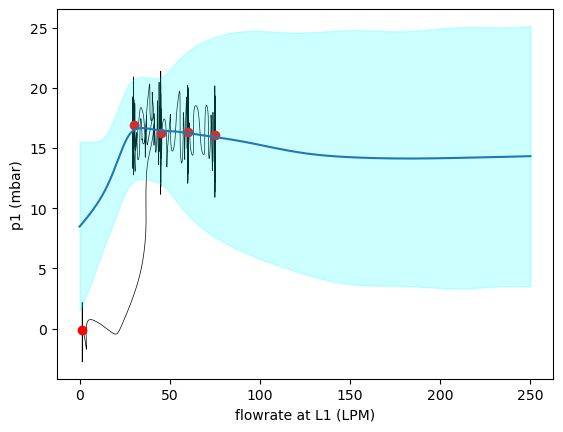

In [18]:
fig, chart = plt.subplots(1, 1)

chart.plot(
    filtered["fl_L1"],  # + filtered["fl_L2"],
    filtered["p1"],  # /0.872,
    color="black",
    linewidth=0.5,
    zorder=0,
)
chart.scatter(
    metrics["fl_L1"], metrics["p1"], color="red", zorder=1  # + metrics["fl_L2"]
)  #
chart.plot(prediction_inputs[:, 0], mean)  # + prediction_inputs[:, 1]
chart.fill_between(
    prediction_inputs[:, 0],  #  + prediction_inputs[:, 1]
    uq_l.ravel(),
    uq_u.ravel(),
    alpha=0.2,
    color="cyan",
)
chart.set_xlabel("flowrate at L1 (LPM)")
chart.set_ylabel("p1 (mbar)")

In [19]:
bh = np.arange(0.8, 1.3, 0.1)
bh = 0.872

fl1 = np.linspace(0, 150, 300)
fl2 = np.ones(300) * 15  # np.linspace(0,30,300)
x1, x2 = np.meshgrid(fl1, fl2, indexing="xy")

inpred = np.column_stack(
    [x1.ravel(order="C"), x2.ravel(order="C"), np.full(x1.size, bh)]
)
inpred.shape

(90000, 3)

In [20]:
mpred, vpred = model.predict_noiseless(inpred)

 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names


minimum stdev =  1.9794628019944394


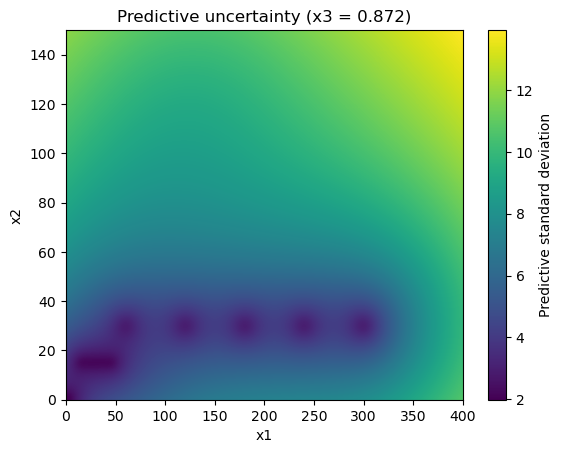

In [21]:
# ---- fixed value of x3 ----
x3_const = 0.872

# ---- grid in (x1, x2) ----
x1 = np.linspace(0, 400, 400)
x2 = np.linspace(0, 150, 300)
X1, X2 = np.meshgrid(x1, x2)

# ---- build full 3D input ----
X_grid = np.column_stack(
    [X1.ravel(order="C"), X2.ravel(order="C"), np.full(X1.size, x3_const)]
)

# ---- GP prediction ----
mean, var = model.predict_noiseless(
    scalerx.transform(X_grid)
)  # var = predictive variance
std = np.sqrt(var).reshape(X1.shape, order="C")  # reshape to grid
print("minimum stdev = ", std.min())

# ---- plot uncertainty ----
plt.figure()
plt.imshow(
    std,
    extent=[x1.min(), x1.max(), x2.min(), x2.max()],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label="Predictive standard deviation")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Predictive uncertainty (x3 = {x3_const})")
plt.show()

 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\skle

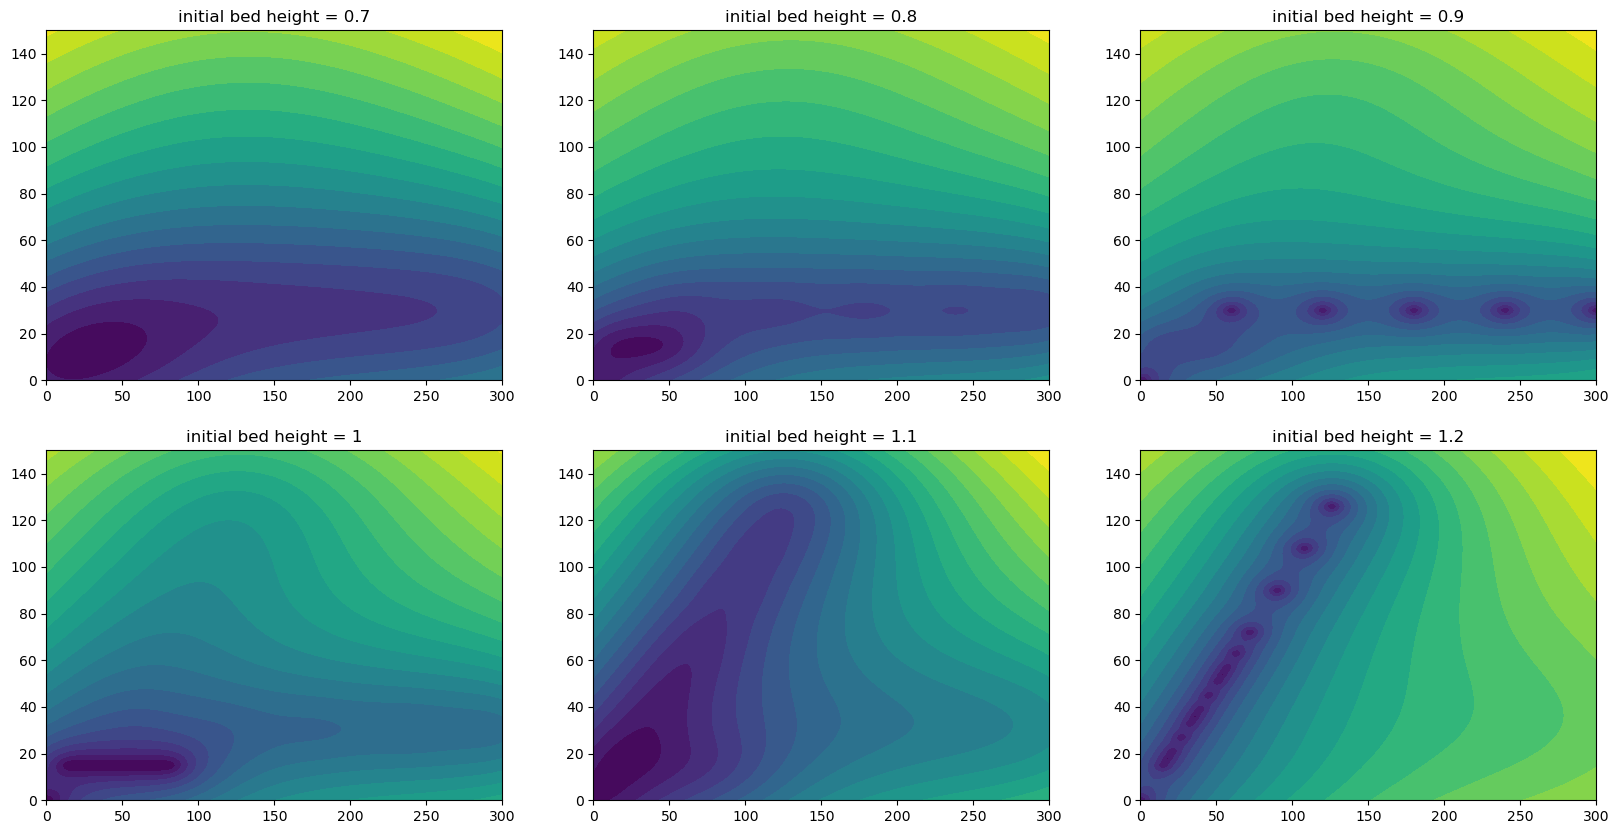

In [22]:
figure, subs = plt.subplots(2, 3)
figure.set_figheight(10)
figure.set_figwidth(20)
j = 0
for i, bh in enumerate([0.7, 0.8, 0.9, 1, 1.1, 1.2]):
    x3_const = bh

    # ---- grid in (x1, x2) ----
    x1 = np.linspace(0, 300, 300)
    x2 = np.linspace(0, 150, 300)
    X1, X2 = np.meshgrid(x1, x2)

    # ---- build full 3D input ----
    X_grid = np.column_stack(
        [X1.ravel(order="C"), X2.ravel(order="C"), np.full(X1.size, x3_const)]
    )

    # ---- GP prediction ----
    mean, var = model.predict_noiseless(
        scalerx.transform(X_grid)
    )  # var = predictive variance
    std = np.sqrt(var).reshape(X1.shape, order="C")  # reshape to grid

    if i < 3:
        subs[j, i].contourf(X1, X2, std, levels=20)
        # subs[j,i].colorbar(label='Predictive Standard Deviation')
        subs[j, i].set_title(f"initial bed height = {bh}")
        continue

    j = 1
    subs[j, i - 3].contourf(X1, X2, std, levels=20)
    subs[j, i - 3].set_title(f"initial bed height = {bh}")


# plt.figure()
# plt.contourf(X1, X2, std, levels=20)
# plt.colorbar(label="Predictive standard deviation")
# plt.xlabel("flowrate at L1 (LPM)")
# plt.ylabel("flowrate at L2 (LPM)")
# plt.title(f"Uncertainty contour (bed height = {x3_const})")
# plt.show()

 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names


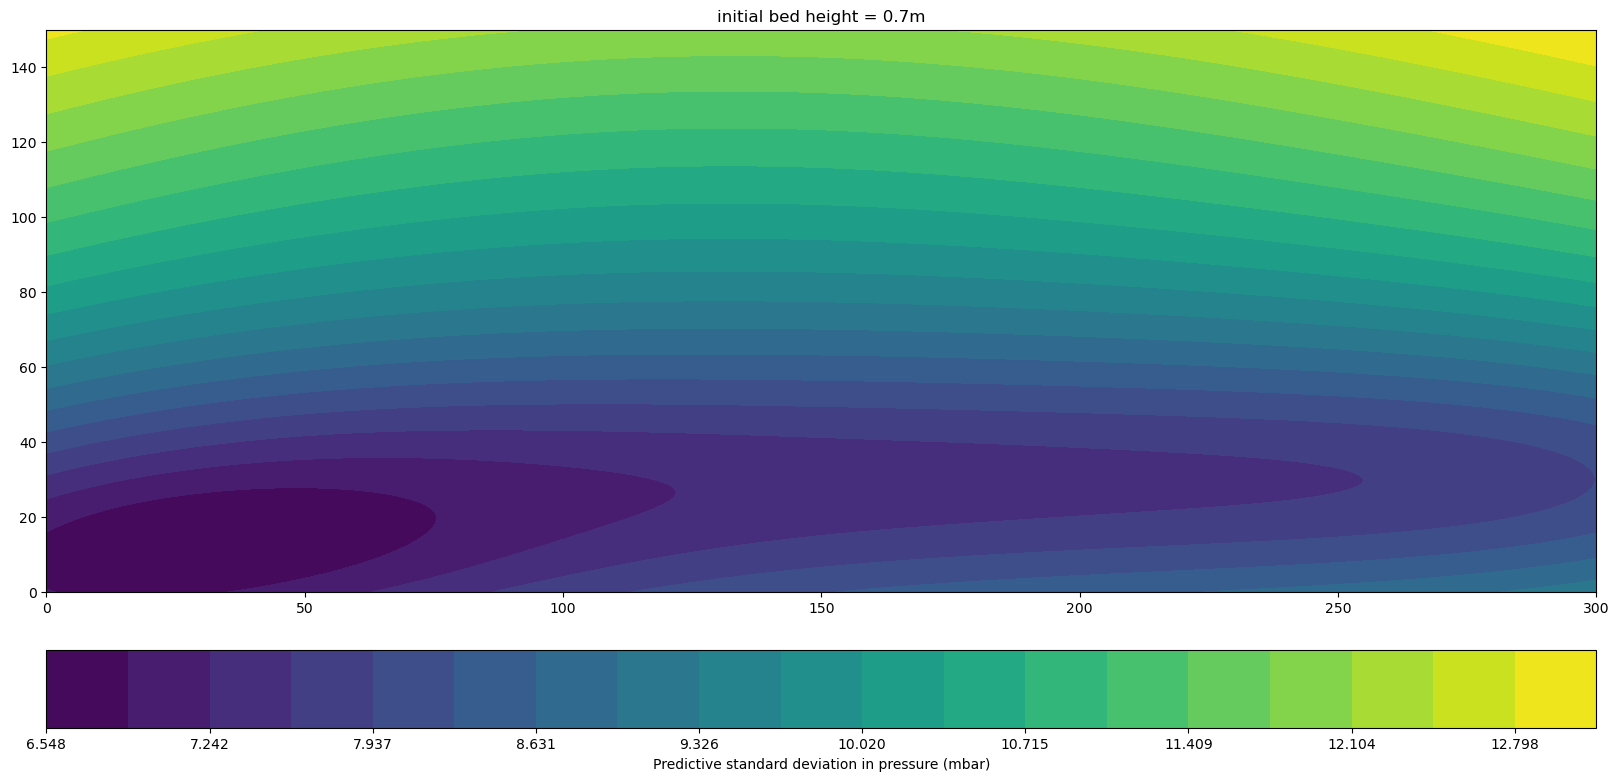

In [23]:
import numpy as np
import matplotlib.pyplot as plt

figure, subs = plt.subplots(1,1, squeeze=False)#(2, 3)
figure.set_figheight(10)
figure.set_figwidth(20)

# ---- store results for shared scaling ----
std_fields = []

# ---- first pass: compute all std fields ----
for bh in [0.7]: #, 0.8, 0.9, 1, 1.1, 1.2]:
    x3_const = bh

    x1 = np.linspace(0, 300, 300)
    x2 = np.linspace(0, 150, 300)
    X1, X2 = np.meshgrid(x1, x2)

    X_grid = np.column_stack(
        [X1.ravel(order="C"), X2.ravel(order="C"), np.full(X1.size, x3_const)]
    )

    mean, var = model.predict_noiseless(scalerx.transform(X_grid))
    std = (np.sqrt(var)).reshape(X1.shape, order="C")

    std_fields.append(std)

# ---- shared color scale ----
vmin = min(Z.min() for Z in std_fields)
vmax = max(Z.max() for Z in std_fields)
levels = np.linspace(vmin, vmax, 20)

# ---- second pass: plotting ----
j = 0
cs = None

for i, (bh, std) in enumerate(zip([0.7, 0.8, 0.9, 1, 1.1, 1.2], std_fields)):

    if i < 3:
        cs = subs[j, i].contourf(X1, X2, std, levels=levels)
        subs[j, i].set_title(f"initial bed height = {bh}m")
        continue

    j = 1
    cs = subs[j, i - 3].contourf(X1, X2, std, levels=levels)
    subs[j, i - 3].set_title(f"initial bed height = {bh}m")


figure.subplots_adjust(bottom=0.15)
# ---- shared colorbar ----
cbar = figure.colorbar(
    cs, ax=subs, orientation="horizontal", location="bottom", pad=0.08
)
cbar.set_label("Predictive standard deviation in pressure (mbar)")

# plt.tight_layout()
plt.show()

In [24]:
from itertools import combinations

In [ ]:
def plot_contour(xrange, yrange, model, bheights):
    if len(bheights) % 2 !=0:
        bheights.append([])
    figure, subs = plt.subplots(len(bheights))
    figure.set_figheight(5*len(bheights))
    figure.set_figwidth(5)
    
    std_fields = []

    x1 = np.linspace(xrange[0], xrange[-1], 500)
    x2 = np.linspace(yrange[0], yrange[-1], 500)
    X1, X2 = np.meshgrid(x1, x2)

    for bh in bheights:
        X_grid = np.column_stack([X1.ravel(order="C"), X2.ravel(order="C"), np.full(X1.size, x3_const)])
        mean, var = model.predict_noiseless(scalerx.transform(X_grid))
        std = (np.sqrt(var)).reshape(X1.shape, order="C")
        std_fields.append(std)

    # ---- shared color scale ----
    vmin = min(Z.min() for Z in std_fields)
    vmax = max(Z.max() for Z in std_fields)
    levels = np.linspace(vmin, vmax, 20)

    # ---- second pass: plotting ----
    cs = None
    for i, (bh, std) in enumerate(zip(bheights, std_fields)):
        cs = subs[i].contourf(X1, X2, std, levels=levels)
        subs[i].set_title(f"initial bed height = {bh}m")

    subs = np.array(subs).reshape(-1,2)
    
    figure.subplots_adjust(bottom=0.15)
    # ---- shared colorbar ----
    cbar = figure.colorbar(
        cs, ax=subs, orientation="horizontal", location="bottom", pad=0.08
    )
    cbar.set_label("Predictive standard deviation in pressure (mbar)")

    plt.show()

 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:X does not have valid feature names, but StandardScaler was fitted with feature names
 c:\Users\Debangshu\anaconda3\envs\FB\lib\site-packages\skle

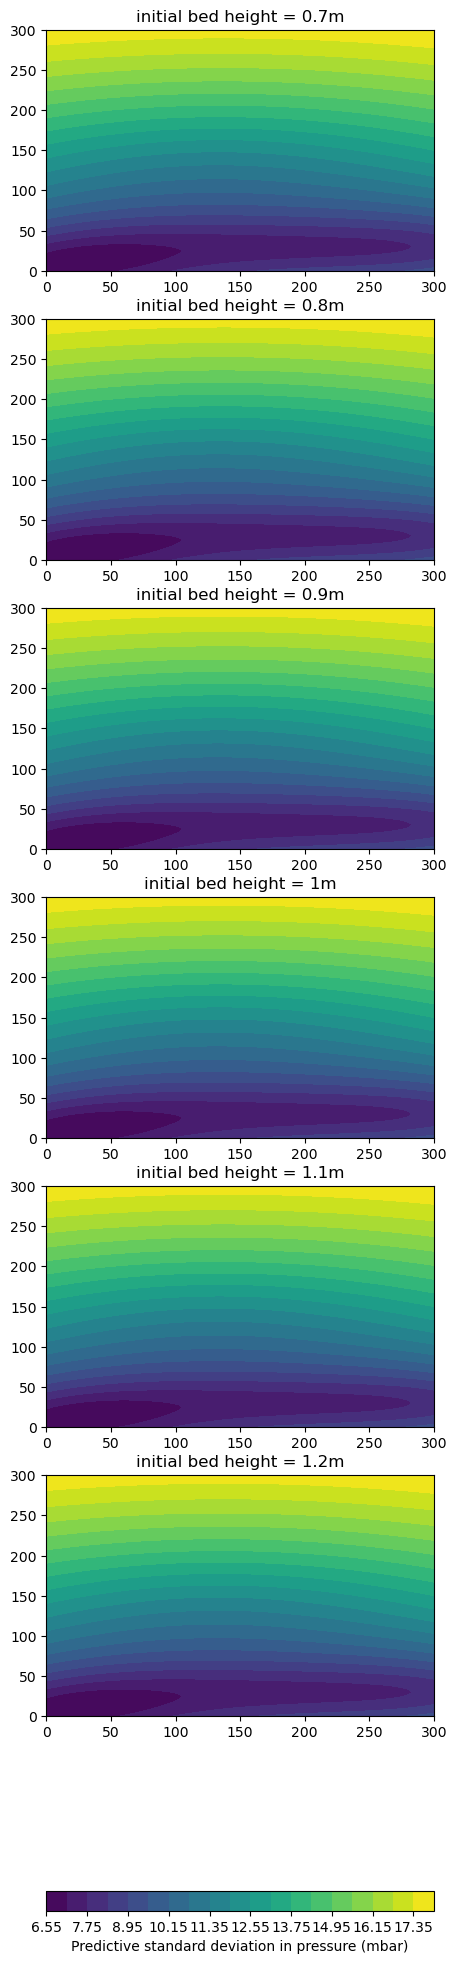

In [33]:
plot_contour(np.array([0,300]), np.array([0,300]), model, [0.7, 0.8, 0.9, 1, 1.1, 1.2])    